In [42]:
!jupyter nbconvert --to html TP5-2024-2025-v2.ipynb

[NbConvertApp] Converting notebook TP5-2024-2025-v2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 819548 bytes to TP5-2024-2025-v2.html


In [34]:

from scipy.signal import convolve2d
from copy import copy
from utils import *
import sys
import numpy as np
import matplotlib.pyplot as plt
plt.ion()
plt.rcParams["image.cmap"] = "gray"

test_utils()


Test utils ok


# Thème Image - TP5 - Synthèse

Ce TP est __noté__.
- Les travaux doivent être postés sur Chamilo (ou envoyés par mail à votre chargé de TP).
- Vous rendrez UN UNIQUE FICHIER au format `html` qui contiendra le compte rendu et les codes.
- Soyez attentifs à correctement commenter et indenter le code pour faciliter la lecture.
- **De manière générale, soyez attentifs à la présentation des résultats et à la 
  rédaction. Le thème de ce TP est l'image, il est donc obligatoire
  d'illustrer votre propos avec les images produites.**

<span style="color:red">**IMPORTANT**</span>

<span style="color:red">**Une fois tous les exercices terminés, vous exporterez le notebook au format HTML. Vous nommerez le fichier</span>

MAP201-\<Code du groupe\>-TP0-\<Prenom1\>-\<Nom1\>-\<Prenom2\>-\<Nom2\>,

<span style="color:red">**où vous remplacerez \<Code du groupe\> par le code de votre groupe de TP (e.g. INF-01) et \<Prenom\> et \<Nom\> par les prénoms et noms de votre binôme.**</span>

<span style="color:red">**C'est ce fichier (ou une conversion au format PDF) que vous devrez poster sur Chamilo (MAP201 / Groupes / Travaux) au plus tard le lendemain de votre séance de TP, à minuit.**
</span>


# Exercice 1 : Egalisation d'histogrammes

1. Ecrire une fonction `egalisation_histogramme(img)` qui prend une image et renvoie l'image après égalisation d'histogramme.

2. Expliquer les effets attendus et les étapes de l'égalisation.
3. Appliquer cette fonction à l'image `ecrevisse.bmp`. Vous afficherez sur un même graphique l'image avant et après égalisation et l'histogramme cumulé avant et après égalisation.

REPONSE: 
2. Expliquer les effets attendus et les étapes de l'égalisation: On a utilisé l'égalisation pour ameliorer le contraste de l'image initale afin de le rendre plus visible.
Les étapes: On calcule l'histogramme et l'histogramme cumulé de l'image, on divise 255/MN (MN est la taille de l'image) et on multiplie par la valeur de ce pixel dans l'histogramme cumulé (H(p)). Ainsi, on attendais un histrogramme cumulé pareil à une rampe qui est bien ce que nous avons obtenu.
Le nombre de pixels dans chaque intervalle augmente de manière uniforme (dans l'histogramme cumulé), ce qui signifie que dans chaque intervalle, nous avons un nombre similaire de pixels de cette couleur.

In [35]:
def egalisation_histogramme(image):
    ### A COMPLETER ###
    
    # histogram
    hist = np.zeros(256)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            hist[image[i, j]] += 1
    #histogram cumule
    H1 = np.zeros(256)
    H1[0] = hist[0]
    for i in range(1, 256):
        H1[i] = H1[i-1] + hist[i]

    MN = image.size
    new_image = copy(image)

    for i in range(new_image.shape[0]):
        for j in range(new_image.shape[1]):
            new_image[i,j]=(255/MN)*H1[new_image[i,j]]
            
    return new_image


Text(0.5, 1.0, 'Histogramme cumule egalise')

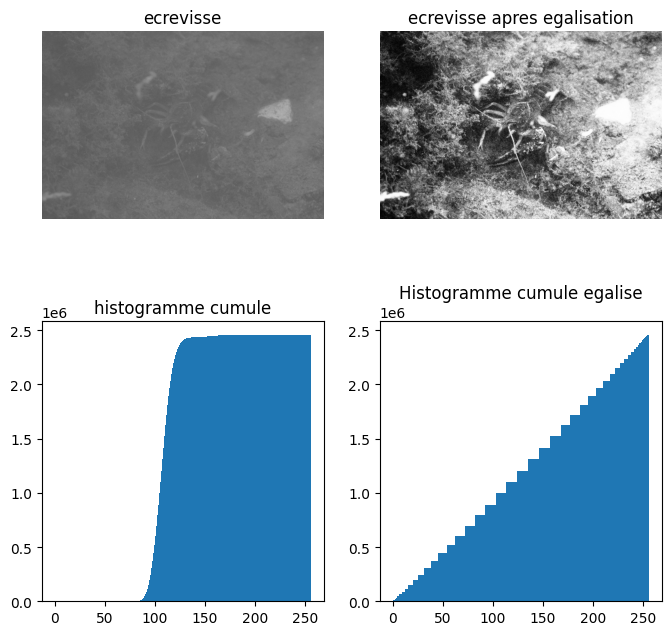

In [36]:
ecrevisse = np.array(plt.imread("ecrevisse.bmp"))
new_ecrevisse = egalisation_histogramme(ecrevisse)
fig, ax = plt.subplots(2,2,figsize=(8,8))
### A COMPLETER ###

ax[0,0].imshow(ecrevisse,vmin=0,vmax=255,cmap='gray')
ax[0,0].set_axis_off()
ax[0,0].set_title('ecrevisse')

ax[0,1].imshow(new_ecrevisse,vmin=0,vmax=255,cmap='gray')
ax[0,1].set_axis_off()
ax[0,1].set_title('ecrevisse apres egalisation')

# histogramme egalise
_,_,_ = ax[1,0].hist(ecrevisse.flatten(), cumulative=True,bins=256, width=1,range=(0,256))
ax[1,0].set_title('histogramme cumule')

# histogramme cumule egalise
_,_,_ =  ax[1,1].hist(new_ecrevisse.flatten(), cumulative=True,bins=256, width=1,range=(0,256))
ax[1,1].set_title('Histogramme cumule egalise')

# Exercice 2 : 
Charger l'image `sweets.bmp` (on la notera $I$). Vous afficherez dans un même graphique toutes les images calculées (ansi que l'original).
1. Soit $W_1 = \begin{bmatrix}-1&-1&-1\\-1&9&-1\\-1&-1&-1\end{bmatrix}$.
- Calculer $I_1=I\star W_1$ (i.e. appliquer le filtre $W_1$ à l'image $I$).
- De quel type de filtre s'agit-il (justifier).
2. Soit $W_m$  le filtre de moyennage de taille `3x3` $W_m = \begin{bmatrix}\frac{1}{9}&\frac{1}{9}&\frac{1}{9}\\\frac{1}{9}&\frac{1}{9}&\frac{1}{9}\\\frac{1}{9}&\frac{1}{9}&\frac{1}{9}\end{bmatrix}$.
- Calculer $I_m = I \star W_m$.
- Calculer $I_2=I + 9(I-I_m)$.
- Vérifier (graphiquement) que les images $I_1$ et $I_2$ sont identiques.

3. Expliquer ce dernier résultat. On pourra remarquer que $I = I \star W_i$ où $W_i = \begin{bmatrix}0&0&0\\0&1&0\\0&0&0\end{bmatrix}$

REPONSE: 
1. De quel type de filtre s'agit-il (justifier): C'est un filtre de masque flou comme le coefficient central est positif, les coefficients extérieurs sont negatifs et la somme des coefficients vaut 1.
2. Expliquer ce dernier résultat. On pourra remarquer que $I = I \star W_i$ où $W_i = \begin{bmatrix}0&0&0\\0&1&0\\0&0&0\end{bmatrix}$ : Les images sont identiques parce que leur différence donne une image complètement noire (valeur 0 pour chaque pixel).

I2 = I + 9 (I - Im) = I * (Wi + 9(Wi - Wm))= I * ( 10Wi - 9Wm) = I * ( $\begin{bmatrix}0&0&0\\0&10&0\\0&0&0\end{bmatrix}$ - $\begin{bmatrix}1&1&1\\1&1&1\\1&1&1\end{bmatrix}$ ) = I * ( $\begin{bmatrix}-1&-1&-1\\-1&9&-1\\-1&-1&-1\end{bmatrix}$ ) = I * W1 =I1

, donc I2=I1

Text(0.5, 1.0, 'I1-I2')

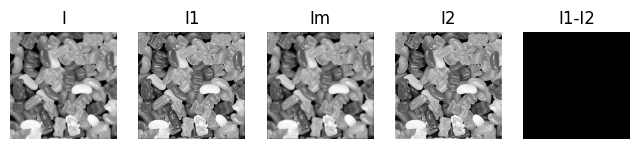

In [37]:

def first(I):
    W1= np.ones((3,3))
    W1=W1*(-1)
    W1[1,1]=9
    return apply_filter_2D(I, W1) # utils.py

def m(I):
    Wm= np.ones((3,3)) /9
    return apply_filter_2D(I, Wm)

def second(I):
    return I + 9*(I-m(I))

# main fonction
I = np.array(plt.imread('sweets.bmp'))
I1=first(I)
Im=m(I)
I2=second(I)


#afficher I, I1, I2
fig, ax = plt.subplots(1,5,figsize=(8,8))
ax[0].imshow(I,vmin=0,vmax=255,cmap='gray')
ax[0].set_axis_off()
ax[0].set_title('I')

ax[1].imshow(I1,vmin=0,vmax=255,cmap='gray')
ax[1].set_axis_off()
ax[1].set_title('I1')

ax[2].imshow(Im,vmin=0,vmax=255,cmap='gray')
ax[2].set_axis_off()
ax[2].set_title('Im')

ax[3].imshow(I2,vmin=0,vmax=255,cmap='gray')
ax[3].set_axis_off()
ax[3].set_title('I2')

ax[4].imshow(I1-I2,vmin=0,vmax=255,cmap='gray')
ax[4].set_axis_off()
ax[4].set_title('I1-I2')


# Exercice 3 : Amélioration des contours
On reprend l'image `penguin-noise.bmp` du précédent TP. Dans la cellule ci-dessous, on redonne certaines fonctions utiles et on applique à l'image un filtre gaussien (avec $\sigma=3$). 

L'objectif de l'exercice est d'améliorer la qualité des contours obtenus par simple seuillage.
On va appliquer la méthode vue en cours, dite d'**élimination des non-maxima locaux**.

Text(0.5, 1.0, 'Contours')

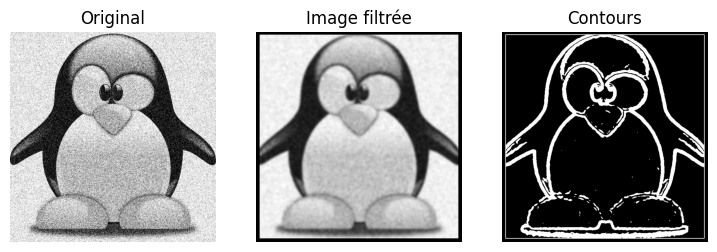

In [38]:
def derivee_partielle_x(im):
    Dx = np.array([[0,0,0],[-0.5,0,0.5],[0,0,0]])
    imx = apply_filter_2D(im,Dx)
    return imx

def derivee_partielle_y(im):
    Dy = np.array([[0,0.5,0],[0,0,0],[0,-0.5,0]])
    imy = apply_filter_2D(im,Dy)
    return imy

def norme_gradient(im):
    imx = derivee_partielle_x(im)
    imy = derivee_partielle_y(im)
    imn = np.sqrt(imx**2 + imy**2)
    return imn

def contours_seuil(im, seuil):
    imn = norme_gradient(im)
    imc = np.zeros_like(im)
    imc = 255 * (imn > seuil)
    return imc

def apply_filter_2D_fast(im, W):
    return convolve2d(im, W, mode='same')

img = np.array(plt.imread("penguin-noise.bmp"))
fil_img = apply_filter_2D(img,get_gauss_filter_2D(3,0.001))
cont_img = contours_seuil(fil_img, 5)

fig, ax = plt.subplots(1,3,figsize=(9,3))
ax[0].imshow(img)
ax[0].set_axis_off()
ax[0].set_title("Original")

ax[1].imshow(fil_img)
ax[1].set_axis_off()
ax[1].set_title("Image filtrée")

ax[2].imshow(cont_img)
ax[2].set_axis_off()
ax[2].set_title("Contours")


## Elimination des non-maxima locaux : la méthode

Afin d'affiner les contours, on réexamine chaque pixel de l'image de contour et on essaie d'identifier s'il correspond à **un maximum de la norme du gradient dans la direction donnée par le vecteur gradient** (qui est la direction de plus grande variation locale).
Ainsi, pour un pixel donné on compare sa valeur à celle de deux de ses voisins, choisis de manière à être les plus proches possibles de la direction du gradient. Il y a quatre cas possibles à choisir en fonction de la direction du gradient, comme illustré ci-dessous avec des exemples où le vecteur gradient est représenté par la flèche en pointillés.

![alt text](pixels.png "pixels")

Etant donnée une image `im`, on applique l'algorithme suivant :
- On calcule:
  - `imx`: la dérivée partielle par rapport à x.
  - `imy`: la dérivée partielle par rapport à y. 
  - `imn`: la norme du gradient.

- On calcule `old_imc` par application d'un seuillage (on pourra utiliser `contour_seuil`).

- Pour chaque pixel `(u,v)` tel que `old_imc(u,v) = 255`:
    - Calcul de l'angle $\phi$ du vecteur gradient $\tt (imx(u,v), imy(u,v))$ avec l'axe $x$, à l'aide de la fonction `np.arctan2` de `numpy` : `phi = np.arctan2(imy(u,v), imx(u,v))`. 
    - Si $\phi \leq 0$, on remplace $\phi$ par $\phi + \pi$, ce qui ne modifie pas la direction et permet de se ramener à une valeur dans l'intervalle $[0, \pi]$.
    - On détermine les pixels voisins qui sont les plus proches de la direction du gradient parmi les quatre cas illustrés ci-dessus en fonction de l'angle $\phi$ :

        - Si $\phi \leq \pi/8$ ou $\phi \geq 7\pi/8$ : cas 1.
        - Si $\pi/8 < \phi \leq 3\pi/8$ : cas 2.
        - Si $3\pi/8 < \phi < 5\pi/8$ : cas 3.
        - Si $5\pi/8 \leq \phi < 7\pi/8$ : cas 4.
    
    (on pourra utiliser la fonction `indices_voisins()` ci-dessous.)

  - On compare la valeur de la norme du gradient dans le pixel central `(u,v)` à celles des deux voisins
    de l'étape précédente ; si une des deux valeurs est strictement supérieure, le pixel central n'est pas 
    un maximum local et on considère qu'il ne fait plus partie du contour : `new_imc(u,v) = 0`. Sinon, `new_imc(u,v) = 255`.

- On retourne `old_imc` et `new_imc`.

![alt text](diagramme.png "pixels")

Il vous est demandé de coder la fonction `elimination_non_max()` (celle-ci doit retourner les deux images de contours : `old_imc` et `new_imc`) et de l'appliquer à l'image `fil_img` (le pingouin bruité après filtrage gaussien) avec un seuil de 5.


In [39]:
def indices_voisins(phi,u,v):
    if phi < np.pi / 8 or phi > 7 * np.pi / 8: # Cas 1
        u1, v1, u2, v2 = u, v-1, u, v+1
    elif np.pi / 8 <= phi < 3 * np.pi / 8: # Cas 2
        u1, v1, u2, v2 = u+1, v-1, u-1, v+1
    elif 3 * np.pi / 8 <= phi < 5 * np.pi / 8: # Cas 3
        u1, v1, u2, v2 = u+1, v, u-1, v
    elif 5 * np.pi / 8 <= phi < np.pi: # Cas 4
        u1, v1, u2, v2 = u+1, v+1, u-1, v-1
    return u1,v1,u2,v2

def elimination_non_max(im,seuil):
    imx = derivee_partielle_x(im)
    imy = derivee_partielle_y(im)
    imn = norme_gradient(im)
    old_imc=contours_seuil(im,seuil)


    new_imc=np.empty(im.shape)
    for u in range(im.shape[0]):
        for v in range(im.shape[1]):
            if old_imc[u,v]==255:
                phi = np.arctan2(imy[u,v], imx[u,v])
                if phi<=0:
                    phi= phi + np.pi
                u1,v1,u2,v2=indices_voisins(phi,u,v)
                if imn[u1,v1]>imn[u,v] or imn[u2,v2]>imn[u,v]:
                    new_imc[u,v]=0
                else:
                    new_imc[u,v]=255

    return old_imc, new_imc


Text(0.5, 1.0, 'new_img')

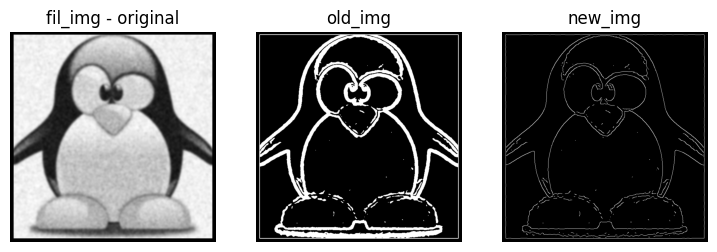

In [40]:
seuil = 5
### A COMPLETER ###
old_img, new_img = elimination_non_max(fil_img,seuil)

fig, ax = plt.subplots(1,3,figsize=(9,3))
ax[0].imshow(fil_img)
ax[0].set_axis_off()
ax[0].set_title("fil_img - original")

ax[1].imshow(old_img)
ax[1].set_axis_off()
ax[1].set_title("old_img")

ax[2].imshow(new_img)
ax[2].set_axis_off()
ax[2].set_title("new_img")